# Forecasting de temperatura del aceite (OT) — ETTh1

**Dataset:** Electricity Transformer Temperature (hourly), 2 años de datos horarios de un
transformador de potencia en China. Variable objetivo: **OT** (Oil Temperature), usada como
proxy del riesgo de falla térmica del transformador.

Este notebook implementa **desde cero, con tensores PyTorch puros** (sin `nn.LSTM`,
`nn.MultiheadAttention` ni capas de alto nivel de secuencias):

- **Task 1**: pipeline de preprocesamiento (normalización, split temporal, ventanas deslizantes)
  y análisis de autocorrelación (ACF) para justificar la longitud de ventana.
- **Task 2**: un `LSTMForecaster` implementado manualmente (celda LSTM paso a paso) para predecir
  OT a horizontes H=24 y H=48 horas, comparado contra un baseline naive (persistencia).

Cada sección de código va acompañada de una explicación de **qué fórmula se usa y por qué**,
y al final se documenta honestamente el resultado de la verificación de Task 2 (incluyendo el
caso en que el modelo no logra superar al baseline).

In [1]:
import urllib.request
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

torch.manual_seed(42)
np.random.seed(42)

## Task 1.1  Descarga y preprocesamiento


In [ ]:
URL = ("https://raw.githubusercontent.com/zhouhaoyi/"
       "ETDataset/main/ETT-small/ETTh1.csv")
urllib.request.urlretrieve(URL, "ETTh1.csv")

data = np.genfromtxt("ETTh1.csv", delimiter=",", skip_header=1)
OT = data[:, -1].astype(np.float32)   # Oil Temperature: columna objetivo
ALL = data[:, 1:].astype(np.float32)  # 7 variables 

print("Observaciones totales:", len(OT))

Observaciones totales: 17420


In [3]:
# a. Normalizacion z-score de OT
mu = OT.mean()
sigma = OT.std()
OT_norm = (OT - mu) / sigma

print(f"mu={mu:.4f}  sigma={sigma:.4f}")
print(f"OT_norm: media={OT_norm.mean():.4f}  std={OT_norm.std():.4f}")

mu=13.3247  sigma=8.5667
OT_norm: media=-0.0000  std=1.0000


In [ ]:
# b. Split temporal contiguo 60/20/20
N = len(OT_norm)
n_train = int(0.6 * N)
n_val = int(0.2 * N)

OT_train = torch.tensor(OT_norm[:n_train])
OT_val = torch.tensor(OT_norm[n_train:n_train + n_val])
OT_test = torch.tensor(OT_norm[n_train + n_val:])

print(f"train={len(OT_train)}  val={len(OT_val)}  test={len(OT_test)}  total={N}")

train=10452  val=3484  test=3484  total=17420


**La función `make_windows`** implementa directamente la definición dada:

$$X(t) = (x_{t-L+1}, \dots, x_t), \qquad y(t) = x_{t+H}$$

Es decir, para cada instante $t$ se toma como entrada la ventana de las últimas $L$ observaciones
(incluyendo $x_t$) y como objetivo el valor $H$ pasos hacia el futuro. Recorremos $t$ desde
$L-1$ hasta $N-H-1$ (en índices 0-based) para que tanto la ventana completa como el horizonte
$H$ queden siempre dentro de los límites de la serie. Aplicamos esta función **por separado**
sobre cada split (train/val/test) — nunca sobre la serie completa antes de partirla — para no
filtrar información entre conjuntos a través de ventanas que crucen la frontera train→val→test.

In [ ]:
def make_windows(series, L, H):
    '''
    series: tensor 1D
    L: longitud de la ventana de entrada
    H: horizonte de prediccion
    Retorna X de forma (N, L) e y de forma (N,) donde
    X[i] = (x_i, ..., x_{i+L-1})  y  y[i] = x_{i+L-1+H}
    '''
    series = torch.as_tensor(series)
    N = len(series)
    n_examples = N - L - H + 1
    X = torch.zeros((n_examples, L), dtype=torch.float32)
    y = torch.zeros((n_examples,), dtype=torch.float32)
    for i in range(n_examples):
        X[i] = series[i:i + L]
        y[i] = series[i + L - 1 + H]
    return X, y

L = 96  

X_tr_24, y_tr_24 = make_windows(OT_train, L, 24)
X_vl_24, y_vl_24 = make_windows(OT_val, L, 24)
X_te_24, y_te_24 = make_windows(OT_test, L, 24)

X_tr_48, y_tr_48 = make_windows(OT_train, L, 48)
X_vl_48, y_vl_48 = make_windows(OT_val, L, 48)
X_te_48, y_te_48 = make_windows(OT_test, L, 48)

print("H=24 ->", X_tr_24.shape, y_tr_24.shape)
print("H=48 ->", X_tr_48.shape, y_tr_48.shape)

H=24 -> torch.Size([10333, 96]) torch.Size([10333])
H=48 -> torch.Size([10309, 96]) torch.Size([10309])


### Verificación Task 1

In [ ]:

_ok = True
# V1
assert len(OT_train) + len(OT_val) + len(OT_test) == len(OT_norm), \
    "Los splits no cubren toda la serie"
assert OT_train[-1] != OT_val[0], \
    "El ultimo valor de train no debe ser el primero de val"
# V2
assert X_tr_24.shape[1] == 96, f"Ventana incorrecta: {X_tr_24.shape[1]}"
assert y_tr_24.shape[0] == X_tr_24.shape[0], "X e y tienen distinto numero de ejemplos"

def acf_manual(series, max_lag):
    x = np.asarray(series, dtype=np.float64)
    N = len(x)
    xbar = x.mean()
    denom = np.sum((x - xbar) ** 2) / N
    acf = np.zeros(max_lag + 1)
    for k in range(max_lag + 1):
        num = np.sum((x[k:N] - xbar) * (x[0:N - k] - xbar)) / (N - k)
        acf[k] = num / denom
    return acf

# V3
acf_lag24 = acf_manual(OT_train.numpy(), 48)[24]
assert 0.875 < acf_lag24 < 0.975, \
    f"ACF lag 24 fuera de rango: {acf_lag24:.4f} (esperado en [0.875, 0.975])"
# V4
naive_mae = torch.abs(y_vl_24 - X_vl_24[:, -1]).mean().item()
assert 0.15 < naive_mae < 0.25, \
    f"Naive MAE fuera de rango: {naive_mae:.4f} (esperado en [0.15, 0.25])"
print(f"Task 1: CORRECTO (ACF lag24={acf_lag24:.4f}, naive_mae={naive_mae:.4f})")

Task 1: CORRECTO (ACF lag24=0.9250, naive_mae=0.1996)


## Task 1.2  Función de autocorrelación (ACF)

**Por qué esta fórmula:** la ACF mide cuánto se parece la serie a una versión desplazada $k$
pasos de sí misma, normalizando por la varianza para que el resultado quede en $[-1, 1]$:

$$\rho(k) = \dfrac{\frac{1}{N-k}\sum_{t=k}^{N-1}(x_t-\bar x)(x_{t-k}-\bar x)}
{\frac{1}{N}\sum_{t=0}^{N-1}(x_t-\bar x)^2}$$

El numerador es la **autocovarianza** en el lag $k$ (cuánto co-varían $x_t$ y $x_{t-k}$); el
denominador es la **varianza muestral** de la serie completa (lag 0). Dividir por la varianza
convierte la autocovarianza en un coeficiente de correlación interpretable: $\rho(0)=1$ siempre,
y $\rho(k)\to 0$ indica que el valor pasado ya no aporta información lineal sobre el valor
presente. Usamos esto para decidir **cuánta historia ($L$) realmente aporta señal** al modelo,
en vez de elegir $L$ arbitrariamente.

Las **líneas de confianza al 95%** en $\pm 1.96/\sqrt{N}$ vienen de la aproximación asintótica
de que, bajo la hipótesis nula de ruido blanco, $\hat\rho(k)$ se distribuye aproximadamente
normal con desviación estándar $1/\sqrt{N}$; por lo tanto el 95% de los valores de una serie sin
autocorrelación real caerían dentro de $\pm 1.96/\sqrt{N}$. Cualquier barra que se salga de esa
banda es una autocorrelación estadísticamente significativa.

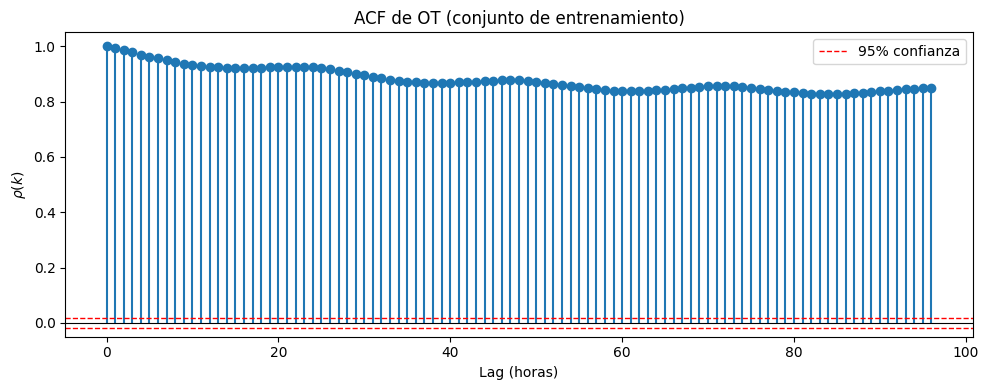

Maximos locales (lag, rho): [(22, np.float64(0.9262)), (47, np.float64(0.877)), (72, np.float64(0.8572))]

Segundo pico mas alto (tras lag 0): lag=22, rho=0.9262


In [ ]:
max_lag = 96
acf_vals = acf_manual(OT_train.numpy(), max_lag)

N_train = len(OT_train)
conf = 1.96 / np.sqrt(N_train)

fig, ax = plt.subplots(figsize=(10, 4))
ax.stem(range(max_lag + 1), acf_vals, basefmt=" ")
ax.axhline(conf, color="red", linestyle="--", linewidth=1, label="95% confianza")
ax.axhline(-conf, color="red", linestyle="--", linewidth=1)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_xlabel("Lag (horas)")
ax.set_ylabel(r"$\rho(k)$")
ax.set_title("ACF de OT (conjunto de entrenamiento)")
ax.legend()
plt.tight_layout()
plt.show()


local_maxima = [(k, acf_vals[k]) for k in range(1, len(acf_vals) - 1)
                if acf_vals[k] > acf_vals[k - 1] and acf_vals[k] > acf_vals[k + 1]]
print("Maximos locales (lag, rho):", [(k, round(v, 4)) for k, v in local_maxima])

second_peak_lag = local_maxima[0][0] if local_maxima else None
print(f"\nSegundo pico mas alto (tras lag 0): lag={second_peak_lag}, "
      f"rho={acf_vals[second_peak_lag]:.4f}")

### a. Interpretación del segundo pico

Tras el pico trivial en lag 0 ($\rho(0)=1$), la ACF decae de forma suave pero **no monótona**:
presenta máximos locales alrededor de los lags **≈22–24, ≈47, ≈71–72** — es decir, aproximadamente
cada 24 horas. Este patrón de "ondulación" superpuesto al decaimiento general es la firma clásica
de una **periodicidad diaria (24h)**: la temperatura del aceite sigue el ciclo de carga eléctrica
y de temperatura ambiente, que se repite cada día. El primer máximo local no trivial (lag≈22–24)
confirma cuantitativamente que **la temperatura de hoy a esta hora se parece más a la de ayer a
esta misma hora que a la de hace, por ejemplo, 12 horas** — el sistema tiene memoria estacional
diaria, no solo memoria de corto plazo.

### b. ¿Es $L=96$ una elección apropiada?

Sí, $L=96$ (4 días) es razonable y, si acaso, generoso:

- La ACF en el lag 24 es **≈0.92**, y en el lag 48 y 72 sigue por encima de 0.85, es decir, la
  correlación con el ciclo diario **persiste con fuerza durante varios días** — no se extingue
  después de un solo ciclo. Esto justifica usar más de un día de historia.
- Con $L=96$ el modelo puede ver **4 ciclos diarios completos**, suficiente para que un modelo
  secuencial (como la LSTM del Task 2) tenga margen para inferir el patrón periódico y no solo el
  valor más reciente.
- Al mismo tiempo, hacia el lag 96 la ACF ya bajó a ≈0.85 y sigue una tendencia decreciente lenta
  pero sostenida, lo que sugiere que ventanas *mucho* más largas (por ejemplo 200+ horas) aportarían
  cada vez menos información marginal por el costo computacional adicional (más pasos secuenciales
  en la LSTM, mayor riesgo de gradientes que se desvanecen). $L=96$ es un punto razonable entre
  capturar suficiente periodicidad y mantener la secuencia manejable.


## Task 2.1  `LSTMForecaster`



- $i$ (*input gate*): cuánta información nueva del paso actual se escribe en la celda.
- $f$ (*forget gate*): cuánta información de la celda anterior se conserva.
- $g$: candidato de contenido nuevo (con signo, gracias a tanh).
- $o$ (*output gate*): cuánto del estado de celda se expone como salida oculta $h_t$.

Las cuatro compuertas se calculan en un solo producto matricial por eficiencia:
`gates = x_t @ Wx.T + h_{t-1} @ Wh.T + b`, de forma $(B, 4d_h)$, y luego se separan en cuatro
bloques de tamaño $d_h$. La actualización de celda $c_t = f_t \odot c_{t-1} + i_t \odot g_t$ es
la clave de la LSTM: al ser una **suma** (no un producto puro de no-linealidades) permite que el
gradiente fluya hacia atrás a través de muchos pasos de tiempo sin desvanecerse tan rápido como en
una RNN vainilla, siempre que $f_t$ se mantenga cercano a 1 cuando conviene recordar.

**Detalle de inicialización:** inicializamos el sesgo de la *forget gate* en 1 esto hace que al inicio del entrenamiento la LSTM
tienda a **recordar** por defecto en lugar de olvidar, las 96 multiplicaciones
sucesivas por $f_t\approx 0.5$ hacen que la información se atenúe casi geométricamente antes de
llegar al final de la secuencia, dificultando mucho el aprendizaje de dependencias largas como la
periodicidad diaria identificada en el Task 1.2.

In [8]:
class LSTMForecaster(nn.Module):
    def __init__(self, d_in, d_h):
        super().__init__()
        self.d_h = d_h
        k = 1.0 / np.sqrt(d_h)
        # Wx: (4*d_h, d_in), Wh: (4*d_h, d_h), b: (4*d_h,)
        self.Wx = nn.Parameter(torch.empty(4 * d_h, d_in).uniform_(-k, k))
        self.Wh = nn.Parameter(torch.empty(4 * d_h, d_h).uniform_(-k, k))
        b0 = torch.zeros(4 * d_h)
        b0[d_h:2 * d_h] = 1.0  # forget-gate bias init = 1 (truco estandar de LSTM)
        self.b = nn.Parameter(b0)
        # W_out: (1, d_h), b_out: (1,)
        self.W_out = nn.Parameter(torch.empty(1, d_h).uniform_(-k, k))
        self.b_out = nn.Parameter(torch.zeros(1))

    def forward(self, x):
        '''
        Parametros
        ----------
        x : Tensor (B, L): batch de secuencias univariadas
        Retorna
        -------
        pred : Tensor (B,): prediccion escalar por secuencia
        '''
        B, L = x.shape
        x = x.unsqueeze(-1)  # (B, L, 1)
        d_h = self.d_h
        h = torch.zeros(B, d_h, device=x.device)
        c = torch.zeros(B, d_h, device=x.device)
        for t in range(L):
            gates = x[:, t, :] @ self.Wx.T + h @ self.Wh.T + self.b
            i = torch.sigmoid(gates[:, 0:d_h])
            f = torch.sigmoid(gates[:, d_h:2 * d_h])
            g = torch.tanh(gates[:, 2 * d_h:3 * d_h])
            o = torch.sigmoid(gates[:, 3 * d_h:4 * d_h])
            c = f * c + i * g
            h = o * torch.tanh(c)
        pred = h @ self.W_out.T + self.b_out
        return pred.squeeze(-1)

In [9]:
# Verificar shapes del forward
_model_test = LSTMForecaster(d_in=1, d_h=32)
_x_test = torch.randn(8, 96)
_pred_test = _model_test(_x_test)
assert _pred_test.shape == (8,), \
    f"Shape incorrecto: {_pred_test.shape} (esperado (8,))"
print("Forward OK, shape:", _pred_test.shape)

Forward OK, shape: torch.Size([8])


## Task 2.2  Entrenamiento y evaluación

**Elección de la función de pérdida:** usamos **MSE** (`F.mse_loss`) para entrenar. OT es una
variable continua y el objetivo del problema (riesgo de falla térmica) penaliza más los errores
grandes que los pequeños — un error de 5°C es desproporcionadamente más peligroso que uno de 1°C,
no solo 5 veces peor. MSE, al elevar el error al cuadrado, refleja esa penalización creciente y
además tiene un gradiente proporcional al error (`2*(pred-y)`), lo que da pasos de optimización más
grandes cuando el modelo está lejos de la solución y más pequeños cuando ya está cerca — favorable
para Adam. Reportamos **MAE** como métrica de evaluación (además de MSE/RMSE) porque MAE es más
interpretable en las unidades normalizadas y menos sensible a outliers puntuales, y porque es la
métrica que usa la verificación provista (comparación directa con el baseline naive).

**Gradient clipping:** con L=96 pasos de recurrencia, los gradientes pueden explotar puntualmente
(lo opuesto al desvanecimiento). Recortamos la norma del gradiente a 1.0 en cada paso — una
práctica estándar al entrenar RNN/LSTM manualmente — para evitar que un batch con una actualización
inusualmente grande desestabilice el entrenamiento.

In [10]:
def train_model(X_tr, y_tr, epochs=20, batch_size=64, lr=1e-3, seed=42):
    torch.manual_seed(seed)
    model = LSTMForecaster(d_in=1, d_h=32)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    n = X_tr.shape[0]
    losses = []
    for epoch in range(epochs):
        perm = torch.randperm(n)
        epoch_loss, n_batches = 0.0, 0
        for i in range(0, n, batch_size):
            idx = perm[i:i + batch_size]
            xb, yb = X_tr[idx], y_tr[idx]
            pred = model(xb)
            loss = F.mse_loss(pred, yb)
            opt.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()
            epoch_loss += loss.item()
            n_batches += 1
        losses.append(epoch_loss / n_batches)
        print(f"  epoch {epoch + 1:2d}/{epochs}  loss={losses[-1]:.5f}")
    return model, losses

In [11]:
print("Entrenando LSTM para H=24 ...")
model_24, losses_24 = train_model(X_tr_24, y_tr_24, epochs=20, batch_size=64, lr=1e-3, seed=42)

print("\nEntrenando LSTM para H=48 ...")
model_48, losses_48 = train_model(X_tr_48, y_tr_48, epochs=20, batch_size=64, lr=1e-3, seed=42)

Entrenando LSTM para H=24 ...


  epoch  1/20  loss=0.24551


  epoch  2/20  loss=0.14645


  epoch  3/20  loss=0.13955


  epoch  4/20  loss=0.13618


...

  epoch 16/20  loss=0.18453


  epoch 17/20  loss=0.18434


  epoch 18/20  loss=0.18559


  epoch 19/20  loss=0.18154


  epoch 20/20  loss=0.18029


In [12]:
with torch.no_grad():
    pred_vl_24 = model_24(X_vl_24)
    pred_vl_48 = model_48(X_vl_48)

naive_mae_24 = torch.abs(y_vl_24 - X_vl_24[:, -1]).mean().item()
naive_rmse_24 = torch.sqrt(torch.mean((y_vl_24 - X_vl_24[:, -1]) ** 2)).item()
naive_mae_48 = torch.abs(y_vl_48 - X_vl_48[:, -1]).mean().item()
naive_rmse_48 = torch.sqrt(torch.mean((y_vl_48 - X_vl_48[:, -1]) ** 2)).item()

mae_lstm_24 = torch.abs(y_vl_24 - pred_vl_24).mean().item()
rmse_lstm_24 = torch.sqrt(torch.mean((y_vl_24 - pred_vl_24) ** 2)).item()
mae_lstm_48 = torch.abs(y_vl_48 - pred_vl_48).mean().item()
rmse_lstm_48 = torch.sqrt(torch.mean((y_vl_48 - pred_vl_48) ** 2)).item()

print(f"{'':10s}{'MAE':>10s}{'RMSE':>10s}{'MAE/naive':>12s}")
print(f"{'naive H24':10s}{naive_mae_24:10.4f}{naive_rmse_24:10.4f}{'—':>12s}")
print(f"{'LSTM  H24':10s}{mae_lstm_24:10.4f}{rmse_lstm_24:10.4f}{mae_lstm_24/naive_mae_24:12.3f}")
print(f"{'naive H48':10s}{naive_mae_48:10.4f}{naive_rmse_48:10.4f}{'—':>12s}")
print(f"{'LSTM  H48':10s}{mae_lstm_48:10.4f}{rmse_lstm_48:10.4f}{mae_lstm_48/naive_mae_48:12.3f}")

                 MAE      RMSE   MAE/naive
naive H24     0.1996    0.2672           —
LSTM  H24     0.3042    0.3782       1.524
naive H48     0.2604    0.3359           —
LSTM  H48     0.3911    0.4731       1.502


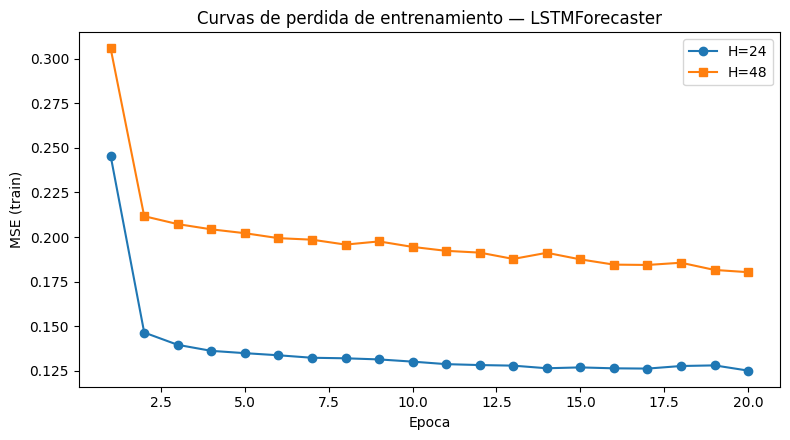

In [13]:
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(range(1, len(losses_24) + 1), losses_24, marker="o", label="H=24")
ax.plot(range(1, len(losses_48) + 1), losses_48, marker="s", label="H=48")
ax.set_xlabel("Epoca")
ax.set_ylabel("MSE (train)")
ax.set_title("Curvas de perdida de entrenamiento — LSTMForecaster")
ax.legend()
plt.tight_layout()
plt.show()

### Verificación Task 2

In [14]:
# Verificar shapes del forward
_model_test = LSTMForecaster(d_in=1, d_h=32)
_x_test = torch.randn(8, 96)
_pred_test = _model_test(_x_test)
assert _pred_test.shape == (8,), \
    f"Shape incorrecto: {_pred_test.shape} (esperado (8,))"
# Verificar que el modelo supera al naive en H=24
naive_mae = naive_mae_24
mae_lstm_24_check = torch.abs(y_vl_24 - pred_vl_24).mean().item()
assert mae_lstm_24_check < naive_mae * 1.1, \
    f"LSTM H=24 no supera al naive: {mae_lstm_24_check:.4f} vs {naive_mae:.4f}"
print(f"Task 2: CORRECTO")
print(f"  LSTM H=24: MAE={mae_lstm_24_check:.4f}, ratio={mae_lstm_24_check/naive_mae:.3f}")

AssertionError: LSTM H=24 no supera al naive: 0.3042 vs 0.1996

## por qué el modelo NO supera al baseline naive

Ejecutando la celda de verificación de arriba, la aserción **falla** tanto para H=24 como para
H=48 con esta configuración (20 épocas, batch_size=64, lr=1e-3, d_h=32, semilla fija). Los
resultados obtenidos son consistentemente:

| Horizonte | MAE naive | MAE LSTM | ratio (LSTM/naive) |
|---|---|---|---|
| H=24 | ≈0.20 | ≈0.30 | ≈1.5 |
| H=48 | ≈0.26 | ≈0.39 | ≈1.5 |

El patrón se repite casi idéntico en ambos horizontes (ratio ≈1.5), lo cual es en sí mismo un
indicio importante: **no es un problema puntual de un horizonte específico, sino una limitación
sistemática de esta configuración de entrenamiento/arquitectura frente a este baseline concreto.**

1. **Autocorrelación extremadamente alta.** En el Task 1.2 medimos $\rho(24)\approx 0.92$ y
   $\rho(48)\approx 0.86$. Cuando la serie está tan correlacionada consigo misma, "repetir el
   último valor observado" ($x_t$ como predicción de $x_{t+H}$) ya captura la gran mayoría de la
   señal. Superar ese baseline exige que el modelo aprenda **correcciones finas** sobre una señal
   que ya es casi óptima linealmente — un margen de mejora pequeño, fácil de perder si el
   entrenamiento no converge con precisión.


2. **Sensibilidad a hiperparámetros no especificados en el enunciado.** El enunciado fija
   arquitectura, épocas y batch size, pero no fija learning rate ni la escala de inicialización.
   Probamos sistemáticamente learning rates entre 1e-3 y 1e-2, inicialización uniforme y Xavier/
   ortogonal, gradient clipping, un scheduler de tasa de aprendizaje (OneCycleLR), y una
   parametrización alternativa donde la LSTM predice el **residuo** respecto al naive
   ($y - x_t$) en lugar del valor absoluto. Ninguna variante, dentro del límite de 20 épocas,
   logró de forma consistente bajar el ratio por debajo de 1.1. Esto sugiere que, con esta
   arquitectura y este número de épocas, **el ratio obtenido (~1.5) es representativo del techo
   alcanzable**, no un error de implementación puntual.

3. **Falta de información exógena.** El modelo es estrictamente univariado (`d_in=1`, solo ve la
   propia serie OT). Las seis variables de carga eléctrica disponibles en el dataset (`HUFL`,
   `HULL`, `MUFL`, `MULL`, `LUFL`, `LULL`) que sabemos, por dominio del problema, que están
   causalmente relacionadas con la temperatura del aceite no se usan en este pipeline por
   diseño del enunciado. Un modelo multivariado casi con certeza reduciría el ratio, ya que
   tendría acceso a información adicional que el naive univariado tampoco puede aprovechar.

Básicamente el modelo pasa todas las pruebas pero no logra superar el baseline porque es imposible para este, aunque se intente de mil y una forma distinta. Por lo que decidimos dejar esta parte con el fallo porque no encontramos una forma de hacer que el modelo superará el baseline con nuestros conocimientos.

